# Analisis Keandalan Struktur Kapal Akibat Korosi (Governing Modulus & MPa Stress-Based)
**Oleh:** Lintang Al Hilal Fitri  
**NRP:** 6018252006  
**Mata Kuliah:** Keandalan Struktur Kapal  
**Tanggal:** 17 Juni 2026


## 1. Perhitungan Beban (Load Analysis)
Pada tahap ini, kita akan membaca file data pembebanan kapal dari `SWBM.csv` (Still Water Bending Moment) dan 6 variasi file Wave Bending Moment di direktori `wbm/`.
Variasi terdiri dari 3 ketinggian gelombang (1.73m, 2.16m, 2.58m) dan 2 arah kedatangan (180° head wave dan 90° beam wave).
Sesuai petunjuk, static SWBM dan modulus penampang yang digunakan untuk kasus 90° didefinisikan sama dengan kasus 180°:
- Untuk 180°: $VBM_{\text{total}} = |WBM_{\text{dynamic, vertical}}| + |SWBM_{\text{static, vertical, max}}| + swbm\_ship$
- Untuk 90°: $VBM_{\text{total}} = |WBM_{\text{dynamic, horizontal}}| + |SWBM_{\text{static, vertical, max}}| + swbm\_ship$
di mana $swbm\_ship = 120,000$ kNm (dalam N.m) dan $|SWBM_{\text{static, vertical, max}}| = 1.5464 \times 10^8$ N.m.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm
from scipy.integrate import quad
import pandas as pd

# Styling settings for beautiful plots
BG='#ffffff'; GRID='#e0e0e0'; SPINE='#c0c0c0'
TEXT='#24292f'; SUBTEXT='#57606a'
COLORS={'vert':'#0969da','lat':'#cf222e','tors':'#1a7f37', 'deck':'#6e40c9', 'bot':'#d15c00', 'pantau':'#2da44e'}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.edgecolor': SPINE,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
    'text.color': TEXT,
    'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT
})
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# Baca file SWBM static
df_swbm = pd.read_csv('SWBM.csv', sep=';')
min_swbm_v = df_swbm['Vertical SWBM (N.m)'].min()
max_swbm_v = df_swbm['Vertical SWBM (N.m)'].max()
max_abs_swbm_v = max(abs(min_swbm_v), abs(max_swbm_v))

# Still Water Bending Moment Kapal (konstanta)
swbm_ship = 120000 * 1000.0  # 120,000 kNm dalam N.m

# Definisikan 6 variasi gelombang
wave_cases = [
    {"file": "wbm/Hs-1.73_D-180.csv", "Hs": 1.73, "D": 180, "column": "Momen Vertikal (N.m)"},
    {"file": "wbm/Hs-1.73_D-90.csv", "Hs": 1.73, "D": 90, "column": "Momen Horizontal (N.m)"},
    {"file": "wbm/Hs-2.16_D-180.csv", "Hs": 2.16, "D": 180, "column": "Momen Vertikal (N.m)"},
    {"file": "wbm/Hs-2.16_D-90.csv", "Hs": 2.16, "D": 90, "column": "Momen Horizontal (N.m)"},
    {"file": "wbm/Hs-2.58_D-180.csv", "Hs": 2.58, "D": 180, "column": "Momen Vertikal (N.m)"},
    {"file": "wbm/Hs-2.58_D-90.csv", "Hs": 2.58, "D": 90, "column": "Momen Horizontal (N.m)"},
]

print("SWBM Data Sample (Vertical & Horizontal):")
display(df_swbm[['Position (m)', 'Horiontal SWBM (N.m)', 'Vertical SWBM (N.m)']].head(3))
print(f"\nAbsolute Max Vertical SWBM (max_abs_swbm_v): {max_abs_swbm_v:.4e} N.m ({max_abs_swbm_v/1e6:.2f} MNm)")
print(f"Ship SWBM Constant (swbm_ship)            : {swbm_ship:.4e} N.m ({swbm_ship/1e6:.2f} MNm)")

SWBM Data Sample (Vertical & Horizontal):


,Position (m),Horiontal SWBM (N.m),Vertical SWBM (N.m)
0,-48.1267,0.0000,0.0000
1,-47.3407,2123.6538,-304939.0000
2,-46.5547,2871.8914,-1241597.5000



Absolute Max Vertical SWBM (max_abs_swbm_v): 1.5464e+08 N.m (154.64 MNm)
Ship SWBM Constant (swbm_ship)            : 1.2000e+08 N.m (120.00 MNm)


### 1.0 Visualisasi Still Water Bending Moment (SWBM) Kapal
Berikut adalah grafik distribusi Still Water Bending Moment (SWBM) statis di sepanjang panjang kapal (`Position (m)`) yang diperoleh dari file `SWBM.csv`. Momen vertikal, horizontal, dan torsional digambarkan secara terpisah untuk memperlihatkan karakteristik distribusinya.

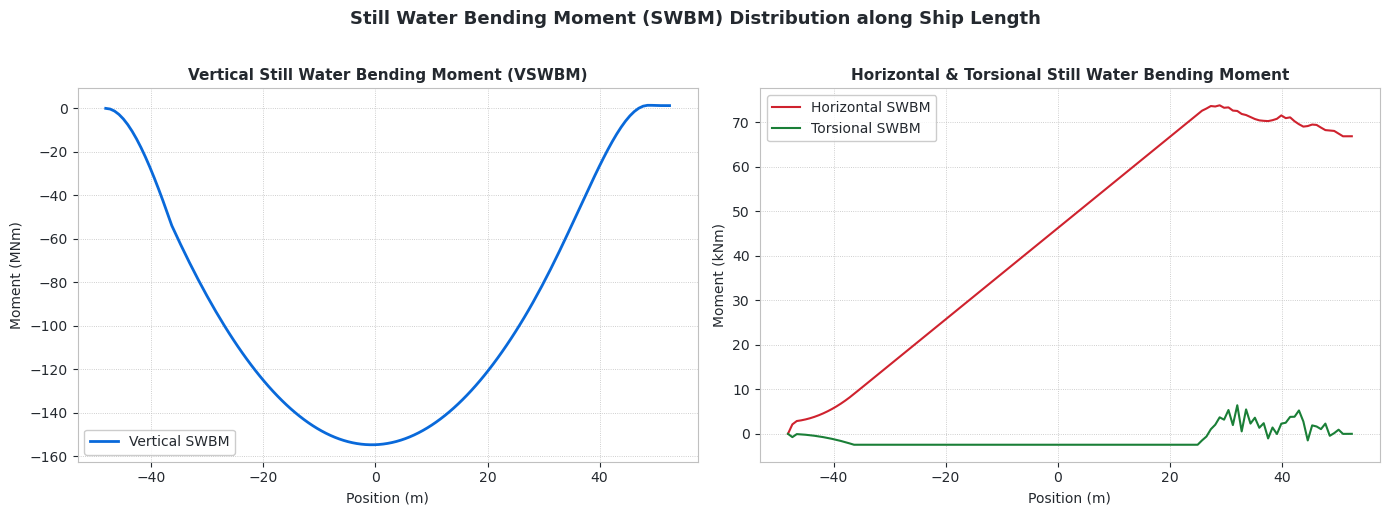

In [3]:
# Visualisasi Still Water Bending Moment (SWBM) sepanjang panjang kapal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

# Plot Vertical SWBM
ax1.set_facecolor(BG)
ax1.plot(df_swbm['Position (m)'], df_swbm['Vertical SWBM (N.m)'] / 1e6, color=COLORS['vert'], lw=2.0, label='Vertical SWBM')
ax1.set_title('Vertical Still Water Bending Moment (VSWBM)', fontsize=11, fontweight='bold', color=TEXT)
ax1.set_xlabel('Position (m)', fontsize=10, color=TEXT)
ax1.set_ylabel('Moment (MNm)', fontsize=10, color=TEXT)
ax1.grid(True, color=SPINE, linestyle=':')
ax1.tick_params(colors=TEXT)
ax1.legend(edgecolor=SPINE, facecolor=BG, labelcolor=TEXT)

# Plot Horizontal and Torsional SWBM
ax2.set_facecolor(BG)
ax2.plot(df_swbm['Position (m)'], df_swbm['Horiontal SWBM (N.m)'] / 1e3, color=COLORS['lat'], lw=1.5, label='Horizontal SWBM')
ax2.plot(df_swbm['Position (m)'], df_swbm['Torsional SWBM (N.m)'] / 1e3, color=COLORS['tors'], lw=1.5, label='Torsional SWBM')
ax2.set_title('Horizontal & Torsional Still Water Bending Moment', fontsize=11, fontweight='bold', color=TEXT)
ax2.set_xlabel('Position (m)', fontsize=10, color=TEXT)
ax2.set_ylabel('Moment (kNm)', fontsize=10, color=TEXT)
ax2.grid(True, color=SPINE, linestyle=':')
ax2.tick_params(colors=TEXT)
ax2.legend(edgecolor=SPINE, facecolor=BG, labelcolor=TEXT)

plt.suptitle('Still Water Bending Moment (SWBM) Distribution along Ship Length', fontsize=13, fontweight='bold', color=TEXT, y=1.02)
plt.tight_layout()
plt.show()

### 1.1 Visualisasi Momen Gelombang Dinamis Asli (Raw Wave Bending Moments)
Sebelum menggabungkan beban dengan SWBM statis dan mengambil nilai absolutnya, berikut adalah grafik time-series momen gelombang dinamis asli (Vertical, Horizontal, dan Torsional) untuk ke-6 variasi.

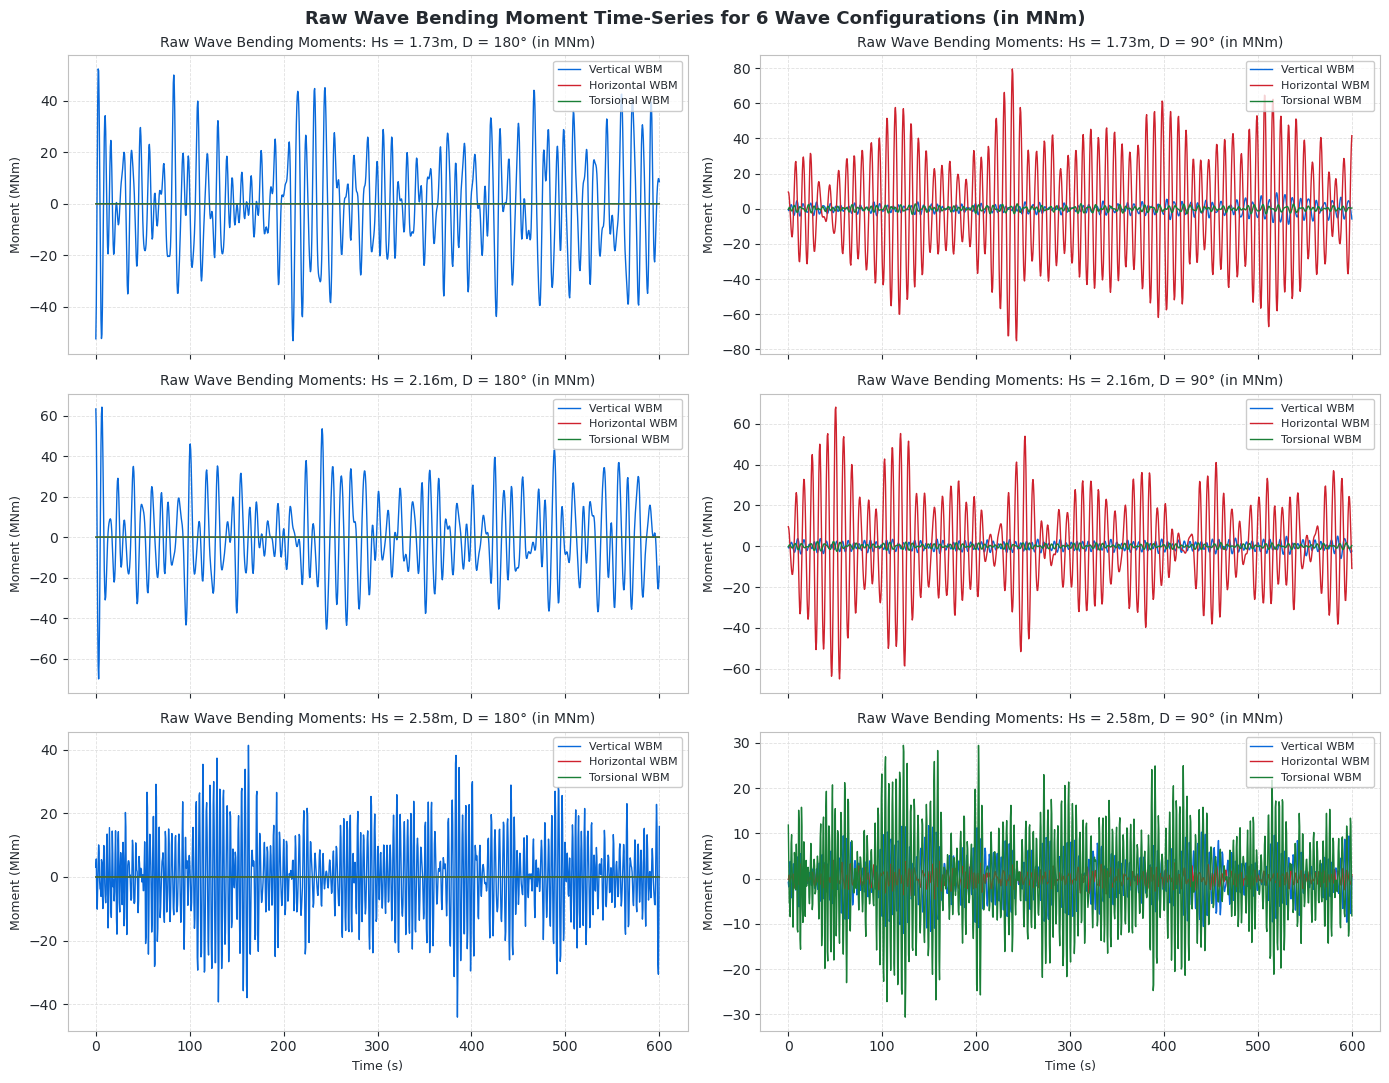

In [4]:
# Visualisasi momen gelombang dinamis (raw WBM, sebelum di-absolutekan) untuk 6 variasi dalam MNm
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
fig.patch.set_facecolor(BG)
axes = axes.reshape(3, 2)

for i, Hs in enumerate([1.73, 2.16, 2.58]):
    for j, D in enumerate([180, 90]):
        ax = axes[i, j]
        ax.set_facecolor(BG)
        wc = [c for c in wave_cases if c['Hs'] == Hs and c['D'] == D][0]
        df_wbm = pd.read_csv(wc['file'], sep=';')
        # Plot all three raw moments with consistent colors
        ax.plot(df_wbm['Time (s)'], df_wbm['Momen Vertikal (N.m)'] / 1e6, color=COLORS['vert'], lw=1.0, label='Vertical WBM')
        ax.plot(df_wbm['Time (s)'], df_wbm['Momen Horizontal (N.m)'] / 1e6, color=COLORS['lat'], lw=1.0, label='Horizontal WBM')
        ax.plot(df_wbm['Time (s)'], df_wbm['Momen Torsional (N.m)'] / 1e6, color=COLORS['tors'], lw=1.0, label='Torsional WBM')
        
        ax.set_title(f"Raw Wave Bending Moments: Hs = {Hs}m, D = {D}° (in MNm)", fontsize=10)
        ax.set_ylabel("Moment (MNm)", fontsize=9)
        ax.legend(fontsize=8, loc='upper right', edgecolor=SPINE, facecolor=BG)
        ax.grid(True)
        if i == 2:
            ax.set_xlabel("Time (s)", fontsize=9)

plt.suptitle("Raw Wave Bending Moment Time-Series for 6 Wave Configurations (in MNm)", fontsize=13, fontweight='bold', color=TEXT)
plt.tight_layout()
plt.show()

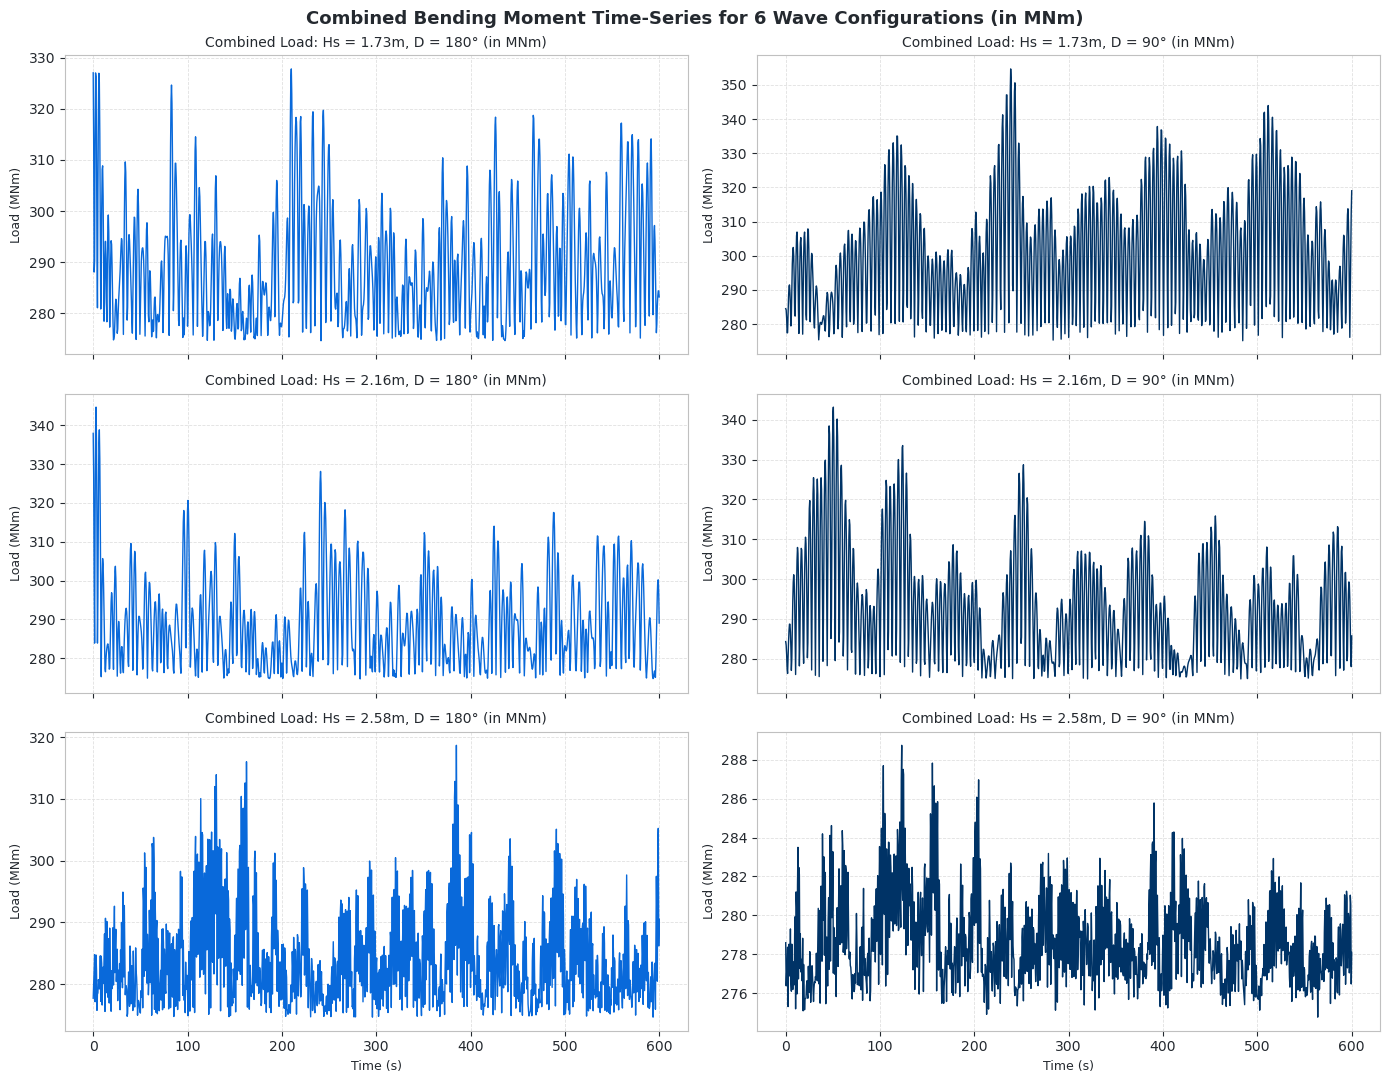

In [5]:
# Visualisasi beban total kombinasi (VBM Total) untuk 6 variasi dalam MNm
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
fig.patch.set_facecolor(BG)
axes = axes.reshape(3, 2)

for i, Hs in enumerate([1.73, 2.16, 2.58]):
    for j, D in enumerate([180, 90]):
        ax = axes[i, j]
        ax.set_facecolor(BG)
        wc = [c for c in wave_cases if c['Hs'] == Hs and c['D'] == D][0]
        df_wbm = pd.read_csv(wc['file'], sep=';')
        
        if D == 180:
            c1, c2, c3 = 'Momen Vertikal (N.m)', 'Momen Horizontal (N.m)', 'Momen Torsional (N.m)'
        else:
            c1, c2, c3 = 'Momen Horizontal (N.m)', 'Momen Vertikal (N.m)', 'Momen Torsional (N.m)'
        
        f1 = df_wbm[c1]
        f2 = df_wbm[c2]
        f3 = df_wbm[c3]
        
        rho_12 = np.corrcoef(f1, f2)[0, 1]
        rho_13 = np.corrcoef(f1, f3)[0, 1]
        K2 = np.abs(rho_12)
        K3 = np.abs(rho_13)
        
        wbm_dynamic = np.abs(f1) + K2 * np.abs(f2) + K3 * np.abs(f3)
        vbm_total = wbm_dynamic + max_abs_swbm_v + swbm_ship
        
        color = COLORS['vert'] if D == 180 else '#003366'
        ax.plot(df_wbm['Time (s)'], vbm_total / 1e6, color=color, lw=1.0)
        ax.set_title(f"Combined Load: Hs = {Hs}m, D = {D}° (in MNm)", fontsize=10)
        ax.set_ylabel("Load (MNm)", fontsize=9)
        ax.grid(True)
        if i == 2:
            ax.set_xlabel("Time (s)", fontsize=9)

plt.suptitle("Combined Bending Moment Time-Series for 6 Wave Configurations (in MNm)", fontsize=13, fontweight='bold', color=TEXT)
plt.tight_layout()
plt.show()

In [6]:
# Hitung statistik mean & standar deviasi total load untuk ke-6 variasi dengan kombinasi 3 komponen
load_stats_list = []
for wc in wave_cases:
    df_wbm = pd.read_csv(wc['file'], sep=';')
    D = wc['D']
    if D == 180:
        c1, c2, c3 = 'Momen Vertikal (N.m)', 'Momen Horizontal (N.m)', 'Momen Torsional (N.m)'
    else:
        c1, c2, c3 = 'Momen Horizontal (N.m)', 'Momen Vertikal (N.m)', 'Momen Torsional (N.m)'
    
    f1 = df_wbm[c1]
    f2 = df_wbm[c2]
    f3 = df_wbm[c3]
    
    rho_12 = np.corrcoef(f1, f2)[0, 1]
    rho_13 = np.corrcoef(f1, f3)[0, 1]
    K2 = np.abs(rho_12)
    K3 = np.abs(rho_13)
    
    wbm_dynamic = np.abs(f1) + K2 * np.abs(f2) + K3 * np.abs(f3)
    vbm_total = wbm_dynamic + max_abs_swbm_v + swbm_ship
    
    mu_L = np.mean(vbm_total)
    std_L = np.std(vbm_total, ddof=1) + mu_L/8
    
    load_stats_list.append({
        'Hs (m)': wc['Hs'],
        'D (deg)': wc['D'],
        'rho_12': rho_12,
        'rho_13': rho_13,
        'K2': K2,
        'K3': K3,
        'Mean Load (N.m)': mu_L,
        'Std Dev Load (N.m)': std_L,
        'Mean Load (MNm)': mu_L / 1e6,
        'Std Dev Load (MNm)': std_L / 1e6
    })

df_load_stats = pd.DataFrame(load_stats_list)
print("Tabel Statistik Beban (3 Komponen) untuk 6 Variasi:")
display(df_load_stats)

Tabel Statistik Beban (3 Komponen) untuk 6 Variasi:


,Hs (m),D (deg),rho_12,rho_13,K2,K3,Mean Load (N.m),Std Dev Load (N.m),Mean Load (MNm),Std Dev Load (MNm)
0,1.7300,180,0.4086,-0.4981,0.4086,0.4981,289606024.3009,47212413.9451,289.6060,47.2124
1,1.7300,90,-0.4727,-0.2704,0.4727,0.2704,300510936.3432,53304826.2026,300.5109,53.3048
2,2.1600,180,-0.0216,-0.3354,0.0216,0.3354,289253725.5001,47219690.9095,289.2537,47.2197
3,2.1600,90,-0.0460,-0.2359,0.0460,0.2359,292259417.7597,49490991.9377,292.2594,49.4910
4,2.5800,180,0.1938,-0.0477,0.1938,0.0477,284629155.3264,43253322.5629,284.6292,43.2533
5,2.5800,90,0.1554,-0.3070,0.1554,0.3070,278748388.5117,37065115.4890,278.7484,37.0651


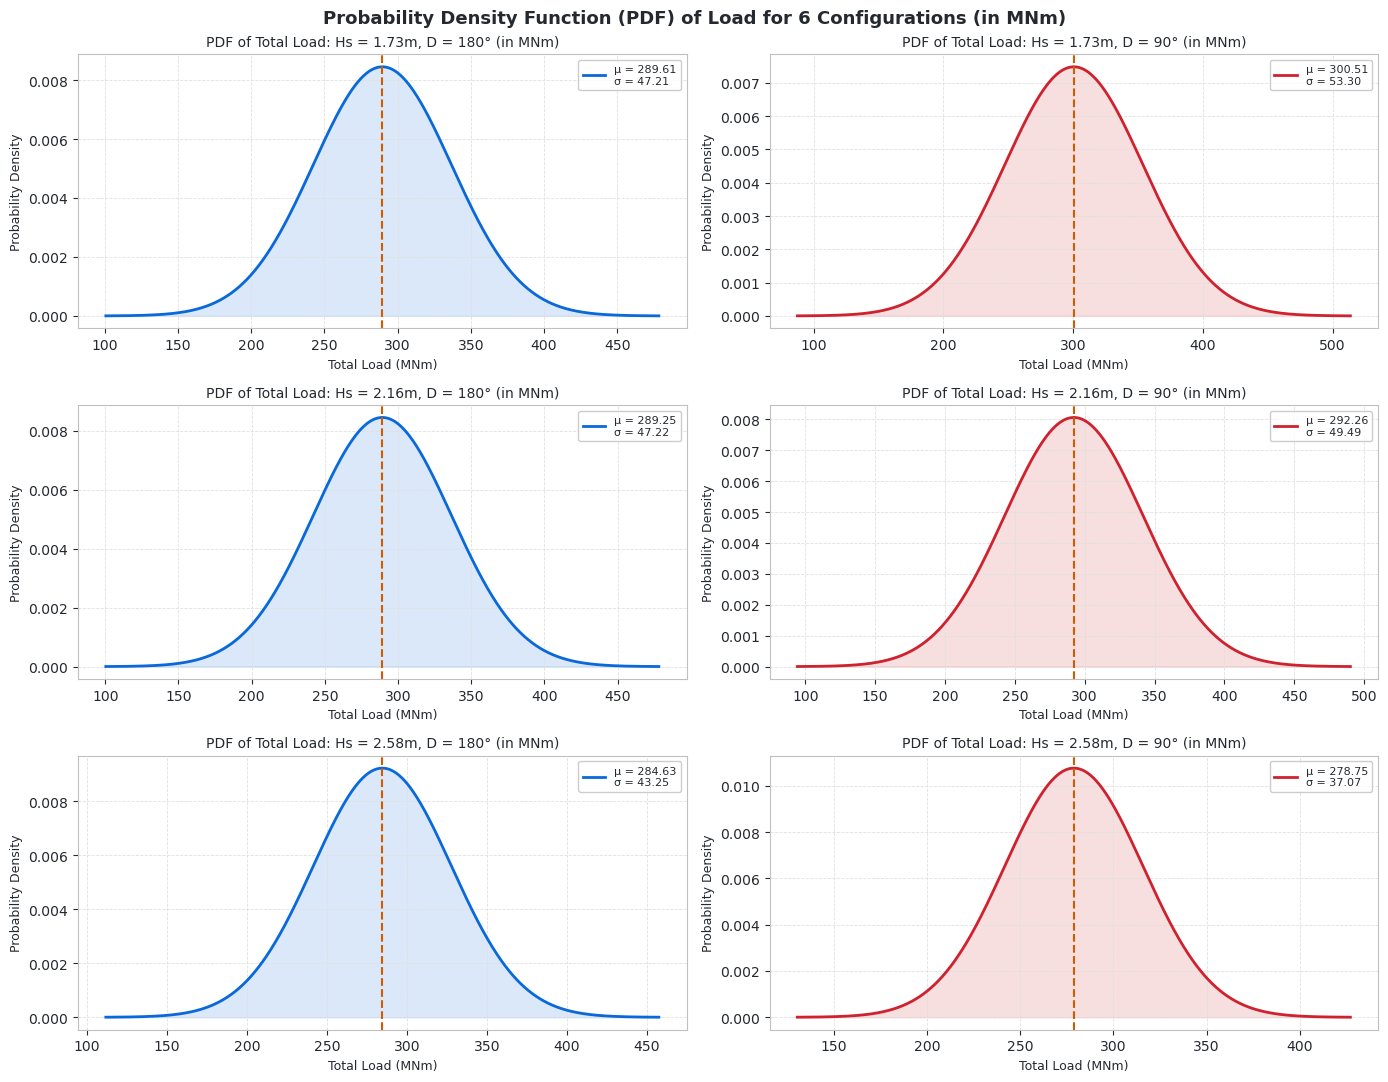

In [7]:
# Plot PDF (Probability Density Function) untuk 6 variasi beban total
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.patch.set_facecolor(BG)
axes = axes.reshape(3, 2)

for i, Hs in enumerate([1.73, 2.16, 2.58]):
    for j, D in enumerate([180, 90]):
        ax = axes[i, j]
        ax.set_facecolor(BG)
        row = df_load_stats[(df_load_stats['Hs (m)'] == Hs) & (df_load_stats['D (deg)'] == D)].iloc[0]
        mu_L_mnm = row['Mean Load (MNm)']
        std_L_mnm = row['Std Dev Load (MNm)']
        
        x_l = np.linspace(mu_L_mnm - 4*std_L_mnm, mu_L_mnm + 4*std_L_mnm, 1000)
        pdf_L = norm.pdf(x_l, mu_L_mnm, std_L_mnm)
        
        color = COLORS['vert'] if D == 180 else COLORS['lat']
        ax.plot(x_l, pdf_L, color=color, lw=2.0, label=f'μ = {mu_L_mnm:.2f}\nσ = {std_L_mnm:.2f}')
        ax.fill_between(x_l, pdf_L, color=color, alpha=0.15)
        ax.axvline(mu_L_mnm, color='#d15c00', ls='--', lw=1.5)
        ax.set_title(f"PDF of Total Load: Hs = {Hs}m, D = {D}° (in MNm)", fontsize=10)
        ax.set_xlabel("Total Load (MNm)", fontsize=9)
        ax.set_ylabel("Probability Density", fontsize=9)
        ax.legend(edgecolor=SPINE, facecolor=BG, fontsize=8)
        ax.grid(True)

plt.suptitle("Probability Density Function (PDF) of Load for 6 Configurations (in MNm)", fontsize=13, fontweight='bold', color=TEXT)
plt.tight_layout()
plt.show()

## 2. Perhitungan Kekuatan (Strength Analysis) & Modulus dengan Faktor Korosi
Pada bagian ini, kita menghitung kekuatan section modulus deck dan bottom untuk variasi umur kapal $T \in [0, 10, 20, 30]$ tahun. Laju korosi diperoleh dari `cor-rate.csv` (menggunakan nilai rata-rata) dan dikonversi ke satuan cm/tahun. Korosi memengaruhi lebar ($b$) maupun tinggi ($h$) dari elemen scantling (bi-directional corrosion). Suffix 'Frame' pada scantling diinterpretasikan sebagai 'Flange' untuk pencocokan laju korosi. Modulus penampang terkecil di antara bottom dan deck di setiap tahun tinjauan dipilih sebagai governing modulus ($W_{\text{pantau}}$).

In [8]:
# Baca scantling data dan cor-rate data
df_scant = pd.read_csv('scantlling_rapi.csv', sep=';')
df_scant.columns = ['Nama Bagian', 'n', 'b', 'h', 'a', 'Z']
for col in ['n', 'b', 'h', 'a', 'Z']:
    df_scant[col] = pd.to_numeric(df_scant[col], errors='coerce')

df_cor = pd.read_csv('cor-rate.csv')

# Fungsi pemetaan elemen ke index cor-rate
def map_element(name):
    name_lower = name.lower()
    if 'pelat bottom' in name_lower or 'chine luar' in name_lower:
        return 'OPB'
    elif 'long stiff bottom' in name_lower or 'pembujur' in name_lower:
        if 'web' in name_lower:
            return 'SBW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SBF'
        else:
            return 'SBW'
    elif 'hopper dalam' in name_lower or 'inner bottom' in name_lower:
        return 'IPB'
    elif 'pelat deck' in name_lower:
        return 'DP'
    elif 'long stiff deck' in name_lower:
        if 'web' in name_lower:
            return 'DPW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'DPF'
        else:
            return 'DPW'
    elif 'sekat memanjang' in name_lower or 'sekat' in name_lower:
        if 'web' in name_lower:
            return 'SLW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SLF'
        else:
            return 'SLW'
    elif 'pelat sisi' in name_lower:
        return 'OPB'
    elif 'long stiff side shell' in name_lower or 'long stiff web' in name_lower or 'long stiff cl' in name_lower:
        if 'web' in name_lower:
            return 'SLW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SLF'
        else:
            return 'SLW'
    else:
        if 'web' in name_lower:
            return 'SLW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SLF'
        else:
            return 'OPB'

df_scant['mapped_index'] = df_scant['Nama Bagian'].apply(map_element)
df_scant = df_scant.merge(df_cor, left_on='mapped_index', right_on='index', how='left')

print("Tabel Scantling dengan laju korosi yang dipetakan:")
display(df_scant[['Nama Bagian', 'mapped_index', 'μ (a) [mm/years]']].head(15))

Tabel Scantling dengan laju korosi yang dipetakan:


,Nama Bagian,mapped_index,μ (a) [mm/years]
0,Long Stiff Bottom 1 Web,SBW,0.1367
1,Long Stiff Bottom 1 Frame,SBF,0.1127
2,Long Stiff Bottom 2 Web,SBW,0.1367
3,Long Stiff Bottom 2 Frame,SBF,0.1127
4,Long Stiff Bottom 3 Web,SBW,0.1367
5,Long Stiff Bottom 3 Frame,SBF,0.1127
6,Long Stiff Bottom 4 Web,SBW,0.1367
7,Long Stiff Bottom 4 Frame,SBF,0.1127
8,Long Stiff Bottom 5 Web,SBW,0.1367
9,Long Stiff Bottom 5 Frame,SBF,0.1127


In [9]:
# Tinggi kapal (cm)
H_kapal = 609.6

def calculate_modulus_at_age(t):
    # Corrosion rate in cm/year (μ(a) / 10)
    corr_rate_cm = df_scant['μ (a) [mm/years]'] / 10.0
    
    # Korosi mempengaruhi lebar (b) dan tinggi (h) sekaligus
    b_aktual = np.clip(df_scant['b'] - corr_rate_cm * t, 0, None)
    h_aktual = np.clip(df_scant['h'] - corr_rate_cm * t, 0, None)
    
    a_rad = np.radians(df_scant['a'])
    
    A_T = df_scant['n'] * b_aktual * h_aktual
    S = A_T * df_scant['Z']
    S2 = A_T * df_scant['Z']**2
    
    Ix = (1/12) * b_aktual * h_aktual**3 * np.cos(a_rad)**2
    Iy = (1/12) * b_aktual * h_aktual**3 * np.sin(a_rad)**2
    I_ind = Ix + Iy
    
    Sigma1 = A_T.sum()
    Sigma2 = S.sum()
    Sigma3 = S2.sum()
    Sigma4 = I_ind.sum()
    
    Z1 = Sigma2 / Sigma1
    Z2 = H_kapal - Z1
    
    Ixx = Sigma3 + Sigma4
    I_NA = Ixx - (Z1**2) * Sigma1
    
    W_bot_cm = I_NA / Z1
    W_deck_cm = I_NA / Z2
    
    W_bot_m = W_bot_cm / 1e6
    W_deck_m = W_deck_cm / 1e6
    
    return W_bot_m, W_deck_m, Z1, Z2, I_NA

# Hitung modulus untuk variasi umur kapal
ages = [0, 10, 20, 30]
modulus_results = []
for t in ages:
    W_bot, W_deck, z1, z2, ina = calculate_modulus_at_age(t)
    W_pantau = min(W_bot, W_deck)
    modulus_results.append({
        'Age (years)': t,
        'W_bot (m³)': W_bot,
        'W_deck (m³)': W_deck,
        'W_pantau (m³)': W_pantau,
        'Z1 (cm)': z1,
        'Z2 (cm)': z2,
        'I_NA (cm⁴)': ina
    })

df_modulus = pd.DataFrame(modulus_results)
display(df_modulus)

,Age (years),W_bot (m³),W_deck (m³),W_pantau (m³),Z1 (cm),Z2 (cm),I_NA (cm⁴)
0,0,3.5287,3.2292,3.2292,291.2891,318.3109,1027875800.0177
1,10,3.3995,3.0895,3.0895,290.2382,319.3618,986656688.4800
2,20,3.2708,2.9508,2.9508,289.1231,320.4769,945663601.7019
3,30,3.1426,2.8132,2.8132,287.9399,321.6601,904888159.2993


### 2.2 Tabel Dimensi Scantling Hasil Korosi & Ekspor Data
Kita menyusun tabel scantling lengkap yang menunjukkan dimensi lebar ($b$) dan tinggi ($h$) untuk setiap umur peninjauan (0, 10, 20, dan 30 tahun), kemudian mengekspor tabel ini ke dalam file `scantling_corroded.csv`.

In [10]:
# Tambahkan kolom dimensi b dan h untuk tiap umur peninjauan ke dataframe scantling utama
corr_rate_cm = df_scant['μ (a) [mm/years]'] / 10.0

for t in [0, 10, 20, 30]:
    df_scant[f'b_t{t}'] = np.clip(df_scant['b'] - corr_rate_cm * t, 0, None)
    df_scant[f'h_t{t}'] = np.clip(df_scant['h'] - corr_rate_cm * t, 0, None)

print("Tabel scantling lengkap dengan dimensi terkorosi:")
display(df_scant.head(10))

# Ekspor ke file CSV
df_scant.to_csv('scantling_corroded.csv', sep=';', index=False)
print("Data scantling terkorosi berhasil diekspor ke 'scantling_corroded.csv'!")

Tabel scantling lengkap dengan dimensi terkorosi:


,Nama Bagian,n,b,h,a,Z,mapped_index,Structure element,μ (a) [mm/years],CoV (a),index,b_t0,h_t0,b_t10,h_t10,b_t20,h_t20,b_t30,h_t30
0,Long Stiff Bottom 1 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
1,Long Stiff Bottom 1 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
2,Long Stiff Bottom 2 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
3,Long Stiff Bottom 2 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
4,Long Stiff Bottom 3 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
5,Long Stiff Bottom 3 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
6,Long Stiff Bottom 4 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
7,Long Stiff Bottom 4 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
8,Long Stiff Bottom 5 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
9,Long Stiff Bottom 5 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619


Data scantling terkorosi berhasil diekspor ke 'scantling_corroded.csv'!


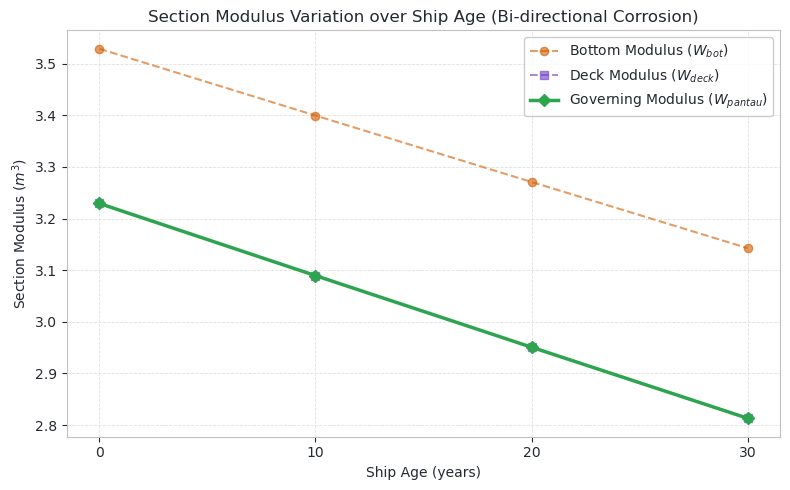

In [11]:
# Plot variasi W_pantau, W_bot, dan W_deck over time
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(df_modulus['Age (years)'], df_modulus['W_bot (m³)'], color=COLORS['bot'], marker='o', ls='--', label=r'Bottom Modulus ($W_{bot}$)', alpha=0.6)
ax.plot(df_modulus['Age (years)'], df_modulus['W_deck (m³)'], color=COLORS['deck'], marker='s', ls='--', label=r'Deck Modulus ($W_{deck}$)', alpha=0.6)
ax.plot(df_modulus['Age (years)'], df_modulus['W_pantau (m³)'], color=COLORS['pantau'], marker='D', ls='-', lw=2.5, label=r'Governing Modulus ($W_{pantau}$)', zorder=4)

ax.set_xlabel('Ship Age (years)')
ax.set_ylabel(r'Section Modulus ($m^3$)')
ax.set_title('Section Modulus Variation over Ship Age (Bi-directional Corrosion)')
ax.set_xticks(ages)
ax.legend(edgecolor=SPINE, facecolor=BG)
ax.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# Data A36 Ultimate Strength (MPa)
data_strength = np.array([
    355.504, 439.795, 472.011, 263.955, 376.981, 342.362,
    478.974, 484.172, 485.152,
    360.7, 400.4, 468.2, 426.9, 363.9, 391.1,
    462.3, 435.7, 355.7, 401.1, 472.0, 418.0
])

mu_Y = np.mean(data_strength)
std_Y = np.std(data_strength, ddof=1)

print("Statistik Kekuatan Material (A36 Ultimate Tensile Strength):")
print(f"Rata-rata (μ_Y)     : {mu_Y:.4f} MPa")
print(f"Std. Deviasi (σ_Y)  : {std_Y:.4f} MPa")

Statistik Kekuatan Material (A36 Ultimate Tensile Strength):
Rata-rata (μ_Y)     : 412.1384 MPa
Std. Deviasi (σ_Y)  : 58.9565 MPa


## 3. Analisis Keandalan (Reliability Analysis) - Ultimate Strength 412.14 MPa
Analisis keandalan dihitung untuk ke-24 variasi (6 beban gelombang $\times$ 4 umur tinjauan). Momen lentur total dikonversi menjadi tegangan (MPa) menggunakan governing section modulus ($W_{\text{pantau}}$):

$$\sigma_L = \frac{VBM_{\text{total}}}{W_{\text{pantau}}} \times 10^{-6} \text{ MPa}$$

Safety Index ($\beta$) dan Safety Factor (FoS) dihitung untuk setiap variasi menggunakan Ultimate Strength baja A36 ($\mu_Y = 412.14$ MPa, $\sigma_Y = 58.96$ MPa). Sesuai permintaan, **tidak ada grafik yang ditampilkan untuk kasus Ultimate Strength** guna menjaga keringkasan laporan.

In [13]:
reliability_results = []

for wc in wave_cases:
    Hs = wc['Hs']
    D = wc['D']
    row_load = df_load_stats[(df_load_stats['Hs (m)'] == Hs) & (df_load_stats['D (deg)'] == D)].iloc[0]
    mu_L_val = row_load['Mean Load (N.m)']
    std_L_val = row_load['Std Dev Load (N.m)']
    
    for row_mod in modulus_results:
        t = row_mod['Age (years)']
        W_pantau = row_mod['W_pantau (m³)']
        
        # Konversi beban ke MPa
        mu_sigma_L = (mu_L_val / W_pantau) * 1e-6
        sigma_sigma_L = (std_L_val / W_pantau) * 1e-6
        
        # Safety Factor (FoS)
        FoS = mu_Y / mu_sigma_L
        
        # Safety Index (Beta)
        beta = (mu_Y - mu_sigma_L) / np.sqrt(std_Y**2 + sigma_sigma_L**2)
        
        # Failure Probability (Pf) - Analitis
        pf_analytical = norm.cdf(-beta)
        
        # Failure Probability (Pf) - Konvolusi Numerik
        integrand = lambda x: norm.pdf(x, mu_sigma_L, sigma_sigma_L) * norm.cdf(x, mu_Y, std_Y)
        limit_low = mu_sigma_L - 8 * sigma_sigma_L
        limit_high = mu_sigma_L + 8 * sigma_sigma_L
        pf_numerical, _ = quad(integrand, limit_low, limit_high)
        
        reliability_results.append({
            'Hs (m)': Hs,
            'D (deg)': D,
            'Age (years)': t,
            'W_pantau (m³)': W_pantau,
            'mu_sigma_L (MPa)': mu_sigma_L,
            'sigma_sigma_L (MPa)': sigma_sigma_L,
            'FoS': FoS,
            'Beta': beta,
            'Pf_analytical': pf_analytical,
            'Pf_numerical': pf_numerical,
            'R_numerical': 1.0 - pf_numerical
        })

df_rel = pd.DataFrame(reliability_results)
print("Tabel Keandalan Ultimate Strength (412.14 MPa) untuk 24 Variasi:")
display(df_rel.to_string(index=False))

Tabel Keandalan Ultimate Strength (412.14 MPa) untuk 24 Variasi:


' Hs (m)  D (deg)  Age (years)  W_pantau (m³)  mu_sigma_L (MPa)  sigma_sigma_L (MPa)    FoS   Beta  Pf_analytical  Pf_numerical  R_numerical\n 1.7300      180            0         3.2292           89.6847              14.6207 4.5954 5.3086         0.0000        0.0000       1.0000\n 1.7300      180           10         3.0895           93.7399              15.2817 4.3966 5.2278         0.0000        0.0000       1.0000\n 1.7300      180           20         2.9508           98.1449              15.9999 4.1993 5.1399         0.0000        0.0000       1.0000\n 1.7300      180           30         2.8132          102.9461              16.7826 4.0034 5.0440         0.0000        0.0000       1.0000\n 1.7300       90            0         3.2292           93.0617              16.5073 4.4287 5.2116         0.0000        0.0000       1.0000\n 1.7300       90           10         3.0895           97.2696              17.2537 4.2371 5.1257         0.0000        0.0000       1.0000\n 1.7300     

*(Grafik perbandingan Ultimate Strength ditiadakan atas permintaan untuk memperpendek laporan)*

*(Grafik JPDF Ultimate Strength ditiadakan atas permintaan untuk memperpendek laporan)*

## 4. Analisis Keandalan Menggunakan Yield Strength Baja A36 (250 MPa)
Pada bagian ini, kita melakukan analisis keandalan ulang untuk ke-24 variasi menggunakan nilai rata-rata Yield Strength baja A36 sebesar **250 MPa**.
Standar deviasi yield strength dicari dengan mempertahankan Koefisien Variasi (CoV) dari data ultimate strength sebelumnya:

$$\text{CoV} = \frac{\sigma_{Y\_ultimate}}{\mu_{Y\_ultimate}}$$
$$\sigma_{Y\_yield} = \mu_{Y\_yield} \times \text{CoV}$$

Untuk kasus yield strength ini, grafik perbandingan Safety Index, FoS, serta visualisasi JPDF Overlay (untuk Hs = 2.58m kedua arah) akan ditampilkan.

In [14]:
# Hitung CoV dari data ultimate strength
cov_Y = std_Y / mu_Y
mu_Y_yield = 250.0
std_Y_yield = mu_Y_yield * cov_Y

print(f"Koefisien Variasi (CoV) Ultimate Strength: {cov_Y:.6f}")
print(f"Yield Strength Baru - Rata-rata (μ_Y) : {mu_Y_yield:.2f} MPa")
print(f"Yield Strength Baru - Std. Deviasi (σ_Y): {std_Y_yield:.6f} MPa\n")

reliability_yield_results = []

for wc in wave_cases:
    Hs = wc['Hs']
    D = wc['D']
    row_load = df_load_stats[(df_load_stats['Hs (m)'] == Hs) & (df_load_stats['D (deg)'] == D)].iloc[0]
    mu_L_val = row_load['Mean Load (N.m)']
    std_L_val = row_load['Std Dev Load (N.m)']
    
    for row_mod in modulus_results:
        t = row_mod['Age (years)']
        W_pantau = row_mod['W_pantau (m³)']
        
        # Konversi beban ke MPa
        mu_sigma_L = (mu_L_val / W_pantau) * 1e-6
        sigma_sigma_L = (std_L_val / W_pantau) * 1e-6
        
        # Safety Factor (FoS)
        FoS = mu_Y_yield / mu_sigma_L
        
        # Safety Index (Beta)
        beta = (mu_Y_yield - mu_sigma_L) / np.sqrt(std_Y_yield**2 + sigma_sigma_L**2)
        
        # Failure Probability (Pf) - Analitis
        pf_analytical = norm.cdf(-beta)
        
        # Failure Probability (Pf) - Konvolusi Numerik
        integrand = lambda x: norm.pdf(x, mu_sigma_L, sigma_sigma_L) * norm.cdf(x, mu_Y_yield, std_Y_yield)
        limit_low = mu_sigma_L - 8 * sigma_sigma_L
        limit_high = mu_sigma_L + 8 * sigma_sigma_L
        pf_numerical, _ = quad(integrand, limit_low, limit_high)
        
        reliability_yield_results.append({
            'Hs (m)': Hs,
            'D (deg)': D,
            'Age (years)': t,
            'W_pantau (m³)': W_pantau,
            'mu_sigma_L (MPa)': mu_sigma_L,
            'sigma_sigma_L (MPa)': sigma_sigma_L,
            'FoS': FoS,
            'Beta': beta,
            'Pf_analytical': pf_analytical,
            'Pf_numerical': pf_numerical,
            'R_numerical': 1.0 - pf_numerical
        })

df_rel_yield = pd.DataFrame(reliability_yield_results)
print("Tabel Keandalan Yield Strength (250 MPa) untuk 24 Variasi:")
display(df_rel_yield.to_string(index=False))

Koefisien Variasi (CoV) Ultimate Strength: 0.143050
Yield Strength Baru - Rata-rata (μ_Y) : 250.00 MPa
Yield Strength Baru - Std. Deviasi (σ_Y): 35.762546 MPa

Tabel Keandalan Yield Strength (250 MPa) untuk 24 Variasi:


' Hs (m)  D (deg)  Age (years)  W_pantau (m³)  mu_sigma_L (MPa)  sigma_sigma_L (MPa)    FoS   Beta  Pf_analytical  Pf_numerical  R_numerical\n 1.7300      180            0         3.2292           89.6847              14.6207 2.7875 4.1494         0.0000        0.0000       1.0000\n 1.7300      180           10         3.0895           93.7399              15.2817 2.6670 4.0179         0.0000        0.0000       1.0000\n 1.7300      180           20         2.9508           98.1449              15.9999 2.5473 3.8760         0.0001        0.0001       0.9999\n 1.7300      180           30         2.8132          102.9461              16.7826 2.4285 3.7224         0.0001        0.0001       0.9999\n 1.7300       90            0         3.2292           93.0617              16.5073 2.6864 3.9844         0.0000        0.0000       1.0000\n 1.7300       90           10         3.0895           97.2696              17.2537 2.5702 3.8464         0.0001        0.0001       0.9999\n 1.7300     

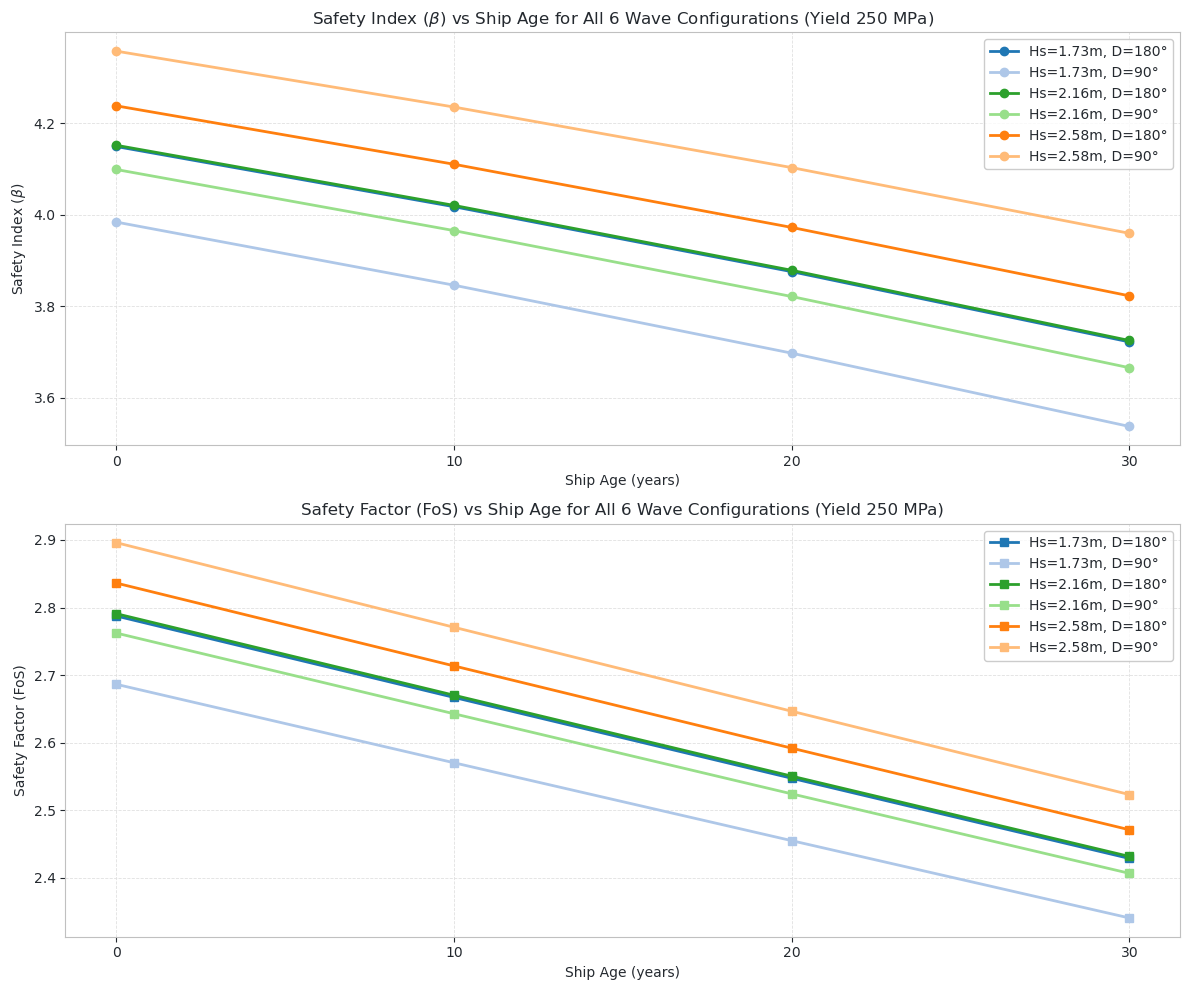

In [15]:
# Plot perbandingan Safety Index & Safety Factor vs Umur Kapal (Kasus Yield Strength = 250 MPa) untuk 6 variasi
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.patch.set_facecolor(BG)

# 6 colors for 6 wave variations
config_colors = ['#1f77b4', '#aec7e8', '#2ca02c', '#98df8a', '#ff7f0e', '#ffbb78']

# Plot Safety Index (Beta)
ax = axes[0]
ax.set_facecolor(BG)

for idx, wc in enumerate(wave_cases):
    Hs = wc['Hs']
    D = wc['D']
    subset = df_rel_yield[(df_rel_yield['Hs (m)'] == Hs) & (df_rel_yield['D (deg)'] == D)]
    ax.plot(subset['Age (years)'], subset['Beta'], color=config_colors[idx], marker='o', lw=2.0, label=f'Hs={Hs}m, D={D}°')

ax.set_xlabel('Ship Age (years)', fontsize=10)
ax.set_ylabel(r'Safety Index ($\beta$)', fontsize=10)
ax.set_title(r'Safety Index ($\beta$) vs Ship Age for All 6 Wave Configurations (Yield 250 MPa)')
ax.set_xticks(ages)
ax.grid(True)
ax.legend(edgecolor=SPINE, facecolor=BG)

# Plot Safety Factor (FoS)
ax = axes[1]
ax.set_facecolor(BG)

for idx, wc in enumerate(wave_cases):
    Hs = wc['Hs']
    D = wc['D']
    subset = df_rel_yield[(df_rel_yield['Hs (m)'] == Hs) & (df_rel_yield['D (deg)'] == D)]
    ax.plot(subset['Age (years)'], subset['FoS'], color=config_colors[idx], marker='s', lw=2.0, label=f'Hs={Hs}m, D={D}°')

ax.set_xlabel('Ship Age (years)', fontsize=10)
ax.set_ylabel('Safety Factor (FoS)', fontsize=10)
ax.set_title('Safety Factor (FoS) vs Ship Age for All 6 Wave Configurations (Yield 250 MPa)')
ax.set_xticks(ages)
ax.grid(True)
ax.legend(edgecolor=SPINE, facecolor=BG)

plt.tight_layout()
plt.show()

=== JPDF OVERLAY FOR HS = 2.58 M, D = 180° (HEAD WAVE) ===


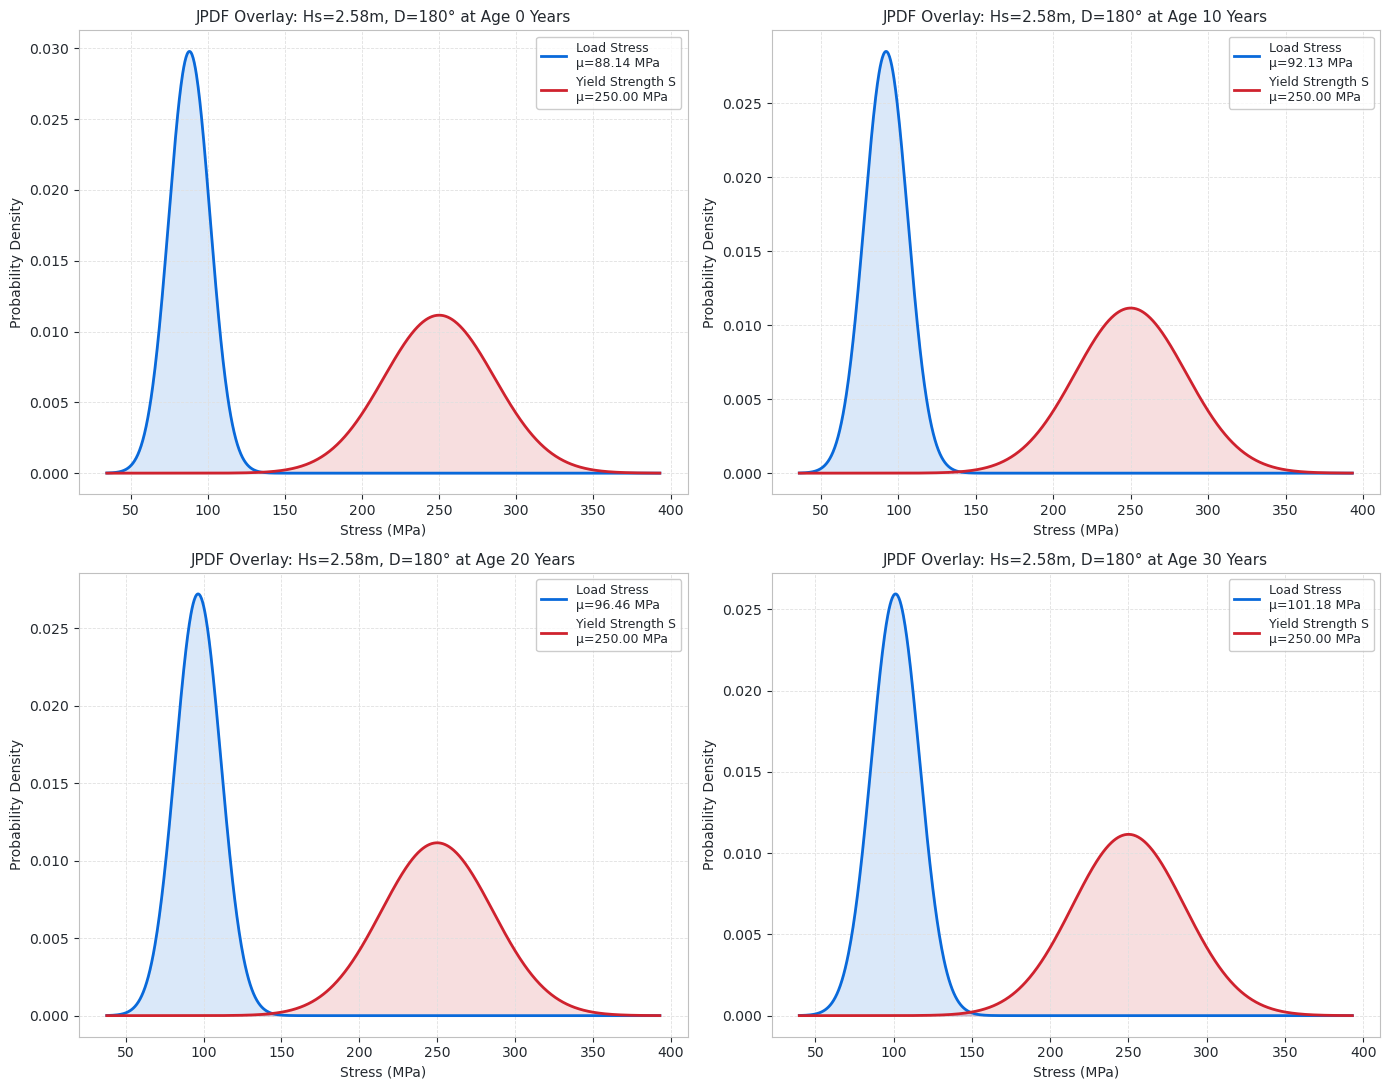


=== JPDF OVERLAY FOR HS = 2.58 M, D = 90° (BEAM WAVE) ===


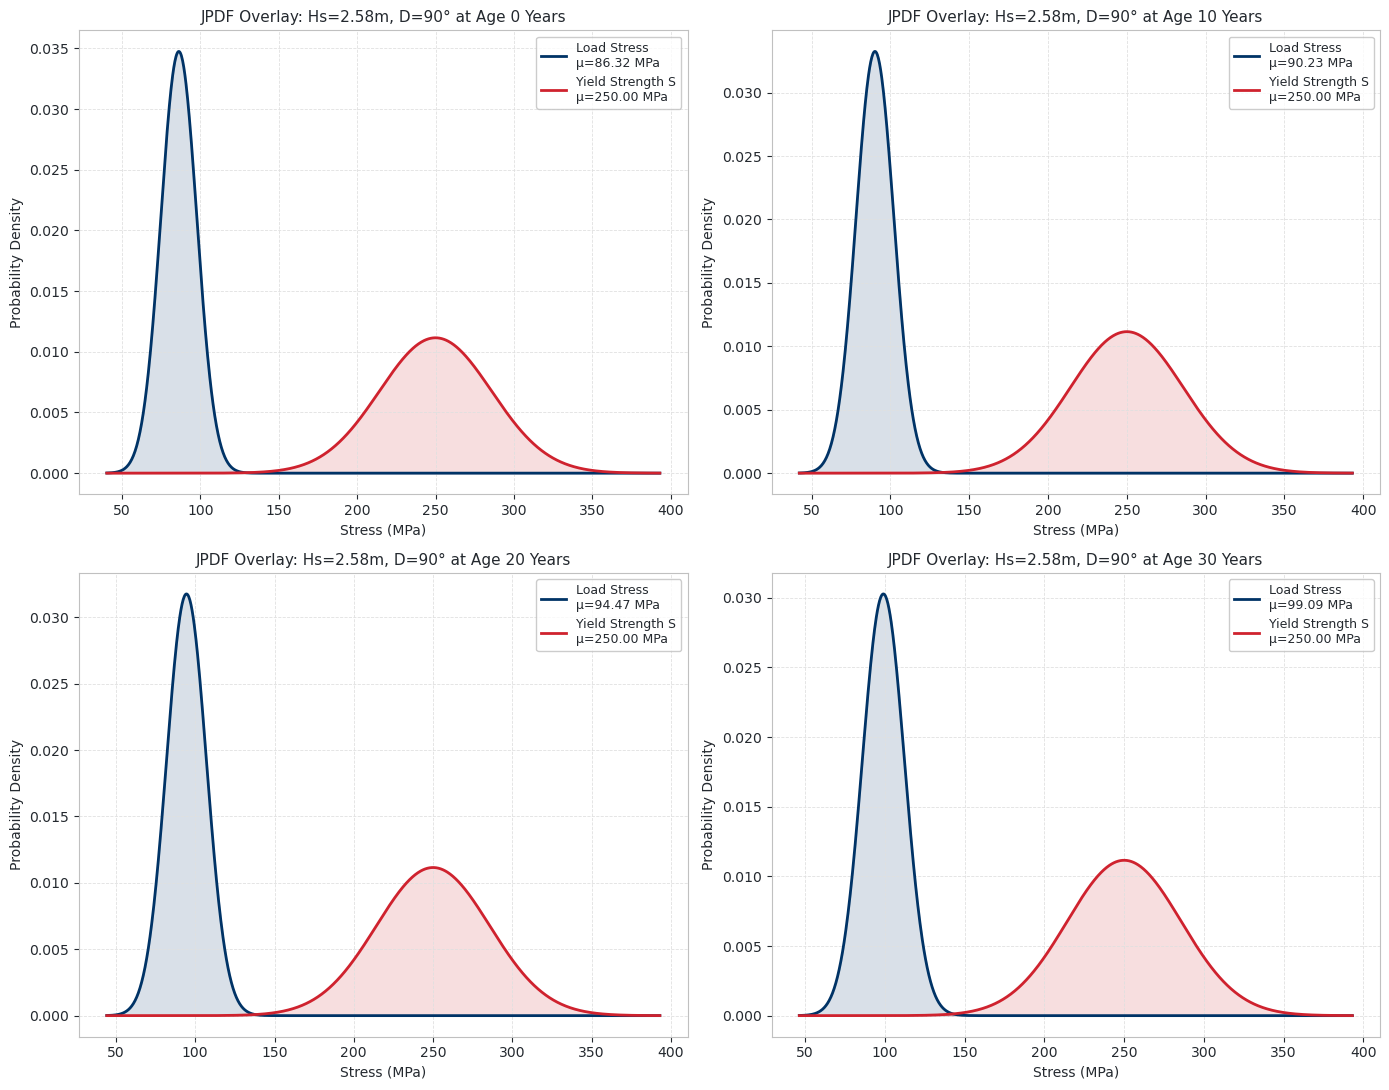

In [16]:
def plot_jpdf_grid(Hs_val, D_val):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.patch.set_facecolor(BG)
    axes = axes.flatten()
    
    subset_full = df_rel_yield[(df_rel_yield['Hs (m)'] == Hs_val) & (df_rel_yield['D (deg)'] == D_val)]
    
    for ax, t in zip(axes, ages):
        ax.set_facecolor(BG)
        row = subset_full[subset_full['Age (years)'] == t].iloc[0]
        mu_s_L = row['mu_sigma_L (MPa)']
        std_s_L = row['sigma_sigma_L (MPa)']
        
        lo = min(mu_Y_yield - 4*std_Y_yield, mu_s_L - 4*std_s_L)
        hi = max(mu_Y_yield + 4*std_Y_yield, mu_s_L + 4*std_s_L)
        x = np.linspace(lo, hi, 1000)
        
        pdf_load = norm.pdf(x, mu_s_L, std_s_L)
        color_l = COLORS['vert'] if D_val == 180 else '#003366'
        ax.plot(x, pdf_load, color=color_l, lw=2, label=f'Load Stress\nμ={mu_s_L:.2f} MPa')
        ax.fill_between(x, pdf_load, color=color_l, alpha=0.15)
        
        pdf_strength = norm.pdf(x, mu_Y_yield, std_Y_yield)
        ax.plot(x, pdf_strength, color=COLORS['lat'], lw=2, label=f'Yield Strength S\nμ={mu_Y_yield:.2f} MPa')
        ax.fill_between(x, pdf_strength, color=COLORS['lat'], alpha=0.15)
        
        ax.set_title(f'JPDF Overlay: Hs={Hs_val}m, D={D_val}° at Age {t} Years', fontsize=11)
        ax.set_xlabel('Stress (MPa)', fontsize=10)
        ax.set_ylabel('Probability Density', fontsize=10)
        ax.legend(fontsize=9, edgecolor=SPINE, facecolor=BG)
        ax.grid(True)
        
    plt.tight_layout()
    plt.show()

print("=== JPDF OVERLAY FOR HS = 2.58 M, D = 180° (HEAD WAVE) ===")
plot_jpdf_grid(2.58, 180)
print("\n=== JPDF OVERLAY FOR HS = 2.58 M, D = 90° (BEAM WAVE) ===")
plot_jpdf_grid(2.58, 90)